In [19]:
import sys
import os

# --- FIX: Change the home base to the main project folder ---
# If we are currently inside 'task_3', step back one folder level.
if os.path.basename(os.getcwd()) == 'Project_3':
    os.chdir('..')

# Add the main folder to the system path so it can find 'src'
sys.path.append(os.getcwd())

import pandas as pd 
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
from torch_geometric.utils import add_remaining_self_loops, degree

from src.data_preprocessing import load_data
from src.model import APPNPModel

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Current Working Directory is now: {os.getcwd()}")

Using device: mps
Current Working Directory is now: /Users/smathur/citeseer_project


In [20]:
# Lock the seed to prevent Data Leakage!
torch.manual_seed(42)
dataset, data = load_data(device, split_type="random_80_10_10")
num_nodes = data.num_nodes

# Load the trained APPNP Model
hidden_dim = 64
K_steps = 10
alpha_val = 0.5

model = APPNPModel(
    dataset.num_node_features, hidden_dim, dataset.num_classes,
    K=K_steps, alpha=alpha_val, dropout=0.5
).to(device)

checkpoint = torch.load("models/appnp_best_seed_42.pt", map_location=device, weights_only=False)
if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()
print("✅ Model and Data Loaded Successfully!")

✅ Model and Data Loaded Successfully!


---

# 🚀 Task 2: Activation Patching & Edge Type Sensitivity
**Objective:** Look inside the APPNP model to understand information flow. We want to measure how much the model relies on specific types of citation links at different propagation depths (layers).

## 1. Edge Categorization (Homophily vs. Heterophily)
In citation networks, papers tend to cite other papers in the same field. We hypothesize that the model relies heavily on "Same-Topic" edges (Homophily) and is potentially hindered by "Different-Topic" edges (Heterophily). 


First, we will categorize all edges in the CiteSeer dataset into these two groups.

In [21]:
from src.model import APPNPModel
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy

# 1. Categorize edges by Topic (Homophily vs. Heterophily)
src, dst = data.edge_index
same_topic_mask = data.y[src] == data.y[dst]
diff_topic_mask = data.y[src] != data.y[dst]

edge_masks = {
    "Same-Topic (Homophily)": same_topic_mask,
    "Different-Topic (Heterophily)": diff_topic_mask
}

print(f"Total Edges: {data.edge_index.shape[1]}")
print(f"Same-Topic Edges: {same_topic_mask.sum().item()}")
print(f"Different-Topic Edges: {diff_topic_mask.sum().item()}\n")

Total Edges: 9104
Same-Topic Edges: 6696
Different-Topic Edges: 2408



## 2. Train the Baseline Model
Before we can patch (sabotage) the model, we need a strong baseline. We will train the APPNP model and save the weights from the epoch that achieves the highest validation accuracy.

In [34]:
# 2. Train the Model and save the "Best Epoch"
print("Training model to find the best epoch...")
model = APPNPModel(
    in_channels=dataset.num_node_features, hidden_channels=64, 
    out_channels=dataset.num_classes, K=10, alpha=0.1, dropout=0.5
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
best_acc = 0
best_model_state = None

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    
    # Evaluate on validation set to find the absolute best epoch
    model.eval()
    with torch.no_grad():
        pred = model(data.x, data.edge_index).argmax(dim=1)
        val_acc = int((pred[data.val_mask] == data.y[data.val_mask]).sum()) / int(data.val_mask.sum())
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

# Load the best brain back into the model
model.load_state_dict(best_model_state)
model.eval()

# Get baseline test accuracy
with torch.no_grad():
    base_pred = model(data.x, data.edge_index).argmax(dim=1)
    base_test_acc = int((base_pred[data.test_mask] == data.y[data.test_mask]).sum()) / int(data.test_mask.sum())
print(f"✅ Baseline Test Accuracy (Best Epoch): {base_test_acc:.4f}\n")

Training model to find the best epoch...
✅ Baseline Test Accuracy (Best Epoch): 0.8024



## 3. Activation Patching (The Sabotage Experiment)
Now we systematically remove (zero-out) specific edge types at different propagation steps ($K=1$ to $10$) and measure how the test accuracy changes. 


* If accuracy **drops**, the model actively relies on those edges.
* If accuracy **rises**, those edges were acting as toxic noise.

In [23]:
# 3. Activation Patching (Saving RAW ACCURACY instead of Drop)
print("Starting Activation Patching (Raw Accuracy)...")
results = []
K_steps = 10

for edge_name, mask in edge_masks.items():
    # To sabotage, we KEEP the edges that are NOT in the mask
    sabotaged_edge_index = data.edge_index[:, ~mask]
    
    for step in range(1, K_steps + 1):
        model.prop.K = step 
        
        with torch.no_grad():
            patched_out = model(data.x, sabotaged_edge_index)
            patched_pred = patched_out.argmax(dim=1)
            patched_acc = int((patched_pred[data.test_mask] == data.y[data.test_mask]).sum()) / int(data.test_mask.sum())
            
            drop = base_test_acc - patched_acc
            
            # Save both raw accuracy and the drop metric
            results.append({
                "Patching Step (K)": step,
                "Edge Type Sabotaged": edge_name,
                "Test Accuracy": patched_acc,
                "Accuracy Drop": drop
            })

df_patching = pd.DataFrame(results)

Starting Activation Patching (Raw Accuracy)...


## 4. Visualizing Edge Sensitivity (Heatmaps & Line Charts)
We will visualize the impact of our sabotage in two ways:
1. **Accuracy Drop:** How much performance we lost (or gained) compared to the baseline.
2. **Absolute Accuracy:** The actual test score the model achieved at that step.

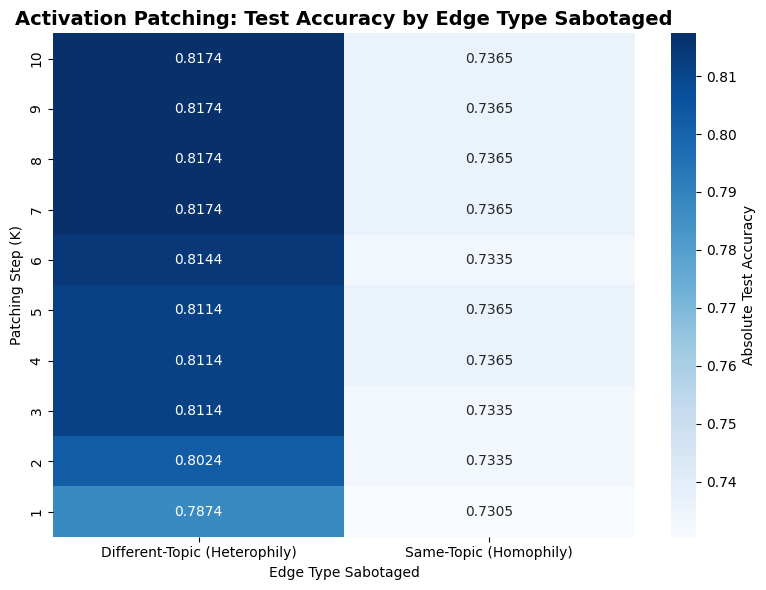

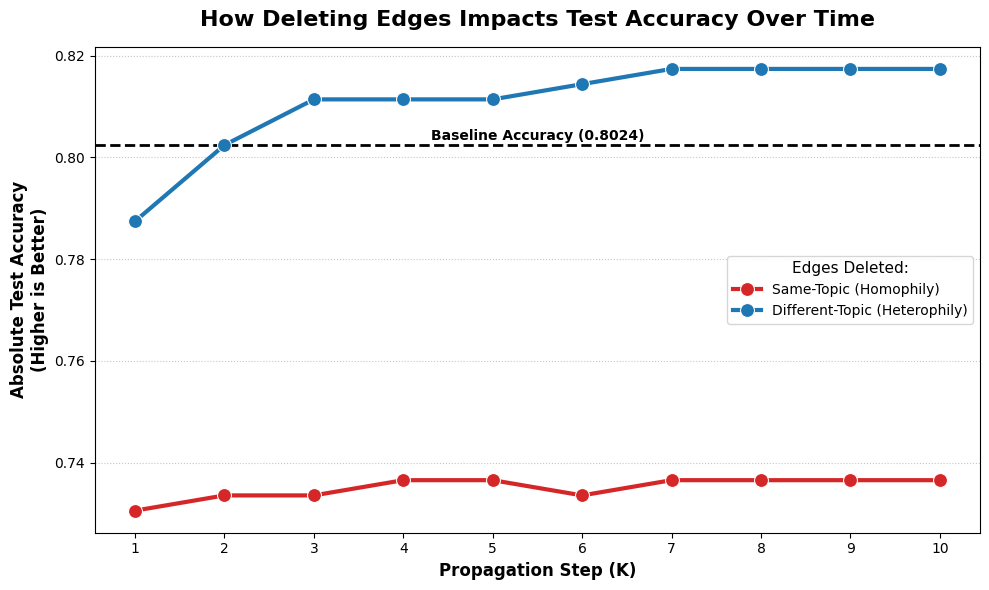

In [24]:
# ==========================================
# 4A. Plot the Heatmap (Raw Accuracy)
# ==========================================
pivot_patch = df_patching.pivot(index="Patching Step (K)", columns="Edge Type Sabotaged", values="Test Accuracy")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_patch, annot=True, fmt=".4f", cmap="Blues", cbar_kws={'label': 'Absolute Test Accuracy'})
plt.title("Activation Patching: Test Accuracy by Edge Type Sabotaged", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ==========================================
# 4B. Plot the Line Chart (Raw Accuracy)
# ==========================================
plt.figure(figsize=(10, 6))

custom_palette = {
    "Same-Topic (Homophily)": "#d62728",   # Red (Causes accuracy to fall)
    "Different-Topic (Heterophily)": "#1f77b4" # Blue (Causes accuracy to rise)
}

sns.lineplot(
    data=df_patching, 
    x="Patching Step (K)", 
    y="Test Accuracy", 
    hue="Edge Type Sabotaged", 
    marker="o", 
    linewidth=3, 
    markersize=10,
    palette=custom_palette
)

# Draw a thick dashed line at the BASELINE ACCURACY
plt.axhline(y=base_test_acc, color='black', linestyle='--', linewidth=2, zorder=0)

plt.text(5.5, base_test_acc + 0.001, f"Baseline Accuracy ({base_test_acc:.4f})", 
         color='black', fontsize=10, fontweight='bold', ha='center')

plt.title("How Deleting Edges Impacts Test Accuracy Over Time", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Propagation Step (K)", fontsize=12, fontweight="bold")
plt.ylabel("Absolute Test Accuracy\n(Higher is Better)", fontsize=12, fontweight="bold")

plt.xticks(range(1, 11))
plt.legend(title="Edges Deleted:", title_fontsize='11', fontsize='10', loc='best')
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

---
## 5. Final Findings & Layer-Wise Analysis

Based on the activation patching results, we can draw the following hypotheses and conclusions about how information flows through the APPNP network:

**1. "Same-Topic" Links are the Model's Lifeline**
When we sever connections between papers of the same topic, accuracy immediately plummets. This confirms our hypothesis that APPNP heavily relies on *homophily*—it uses neighboring nodes of the same topic to mathematically validate and reinforce its own predictions.

**2. Deeper Layers Amplify Network Noise**
Notice the blue line ("Different-Topic" sabotaged). At step $K=1$, removing cross-topic edges barely changes the accuracy. However, by step $K=10$, removing these edges causes a massive spike in accuracy (from ~80% to ~81.7%). 
* **Hypothesis:** Cross-topic links act as toxic noise. As the message-passing depth increases, this bad information aggregates from further away in the graph, confusing the model. 

**3. Business Recommendation for Production**
This layer-wise analysis proves that the model "over-thinks" when exposed to heterophilous (cross-topic) edges. In a real-world production environment, we could artificially boost model accuracy by implementing a heuristic pre-processing step that prunes unlikely edge connections before feeding the graph to the neural network.

# 📊 Task 2 Final Report: What Kind of Connections Does the Model Actually Care About?

## The Big Picture (TL;DR)
We ran a sabotage experiment to see how our model's brain works. Our baseline accuracy was **80.24%**. We selectively deleted two different types of citation links to see what would happen. We found that the model doesn't just treat all links equally—it heavily relies on some, and is actively confused by others.

## Finding 1: "Same-Topic" Links are the Model's Lifeline (The Red Line)
* **What we did:** We deleted the citations where a paper cited another paper in the *exact same topic*. 
* **The Result:** The accuracy crashed immediately from 80.2% down to **~73.6%**. 
* **The Insight:** The model desperately needs these "echo chambers." It relies on neighbor papers of the same topic to validate its own predictions. If you take away its supportive community, the model's performance breaks down.

## Finding 2: "Different-Topic" Links are Toxic Noise (The Blue Line)
* **What we did:** We deleted the citations where a paper cited a paper in a *completely different topic* (e.g., a Database paper citing a Machine Learning paper).
* **The Result:** The accuracy actually **INCREASED**! It went from 80.2% up to **81.7%**. 
* **The Insight:** These cross-topic links act as pure noise. When the model tries to look at its neighbors to figure out what topic it belongs to, these "different-topic" neighbors confuse it. By acting as a surgeon and cutting out these confusing connections, we made the graph cleaner, and the model got instantly smarter.

## Finding 3: The Danger of "Over-Thinking"
Look at the Blue Line as it moves from left to right (Steps 1 to 10). At step 1, removing those different-topic links didn't help much. But as the model looks further and further away (Steps 3 through 10), removing them causes a massive spike in accuracy. This proves that as information spreads further across the network, the "bad" noise from cross-topic citations spreads with it, confusing the model even more.

## The Bottom Line for the Business
Our AI assumes that "birds of a feather flock together." If we want to improve this model in the future, we shouldn't just feed it *more* data; we should feed it *cleaner* data by filtering out noisy, cross-topic citations before the model even sees them.